In [2]:
# Importando livrarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [3]:
# carrega base de dados
df = pd.read_csv("vinhos_dataset_reduced.csv")

In [4]:
# Verificando a distribuição dos vinhos por cor
df['color'].value_counts()

color
white    3961
red      1359
Name: count, dtype: int64

In [6]:

# Definindo os features e mostrando o cabecario e 5 linhas
features = ['citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'combined_acidity',
       'combined_sulfur_dioxide', 'quality']
X = df[features].copy()
X.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,combined_acidity,combined_sulfur_dioxide,quality
0,-2.164515,-0.699699,0.523880,1.100996,1.779304,0.177941,-0.969152,1.594818,-1.753919,5
1,-2.164515,-0.544135,1.120736,0.763753,-0.153797,0.979389,-0.631833,2.565734,-0.786828,5
2,-1.892672,-0.610806,0.957957,0.831202,0.220351,0.779027,-0.631833,2.061356,-1.345931,5
3,1.641293,-0.699699,0.496751,1.168444,-0.403229,0.311515,-0.631833,1.865803,-1.191760,6
4,-2.164515,-0.721923,0.496751,1.100996,1.779304,0.177941,-0.969152,1.426692,-1.599748,5


In [7]:
# Faz o scaler dos "features" usando o standardscaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-2.16451528, -0.69969941,  0.52388033,  1.10099559,  1.77930357,
         0.1779407 , -0.96915199,  1.44699582, -1.33716057, -0.90449728],
       [-2.16451528, -0.54413546,  1.12073572,  0.76375321, -0.15379707,
         0.97938943, -0.63183308,  2.32791859, -0.59986579, -0.90449728],
       [-1.89267181, -0.61080573,  0.95795697,  0.83120168,  0.22035144,
         0.77902725, -0.63183308,  1.87029052, -1.02611677, -0.90449728],
       [ 1.64129325, -0.69969941,  0.49675054,  1.16844407, -0.40322942,
         0.31151549, -0.63183308,  1.69286382, -0.90857958,  0.23226755],
       [-2.16451528, -0.72192284,  0.49675054,  1.10099559,  1.77930357,
         0.1779407 , -0.96915199,  1.29445313, -1.21962337, -0.90449728]])

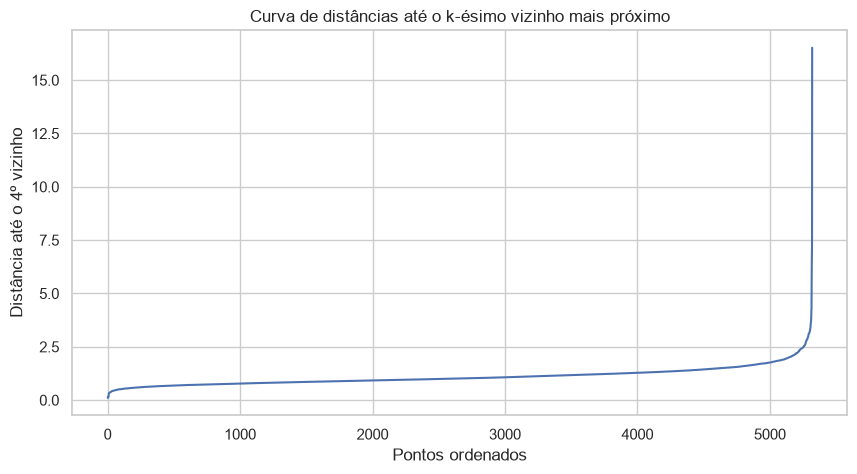

In [8]:
# Apoio para escolha de `eps` com gráfico de distâncias
min_samples = 4

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distancias_k = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 5))
plt.plot(distancias_k)
plt.title('Curva de distâncias até o k-ésimo vizinho mais próximo')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância até o {min_samples}º vizinho')
plt.show()

In [9]:
eps_escolhido = 2.5
dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_samples)
clusters = dbscan.fit_predict(X_scaled)

In [ ]:
df['cluster'] = clusters
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,cluster
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152,5,red,0
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833,5,red,0
2,0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833,5,red,0
3,3.019841,-0.381197,1.641293,-0.699699,0.496751,-0.732258,-0.953146,1.168444,-0.403229,0.311515,-0.631833,6,red,0
4,0.140064,1.877583,-2.164515,-0.721923,0.496751,-0.956934,-1.305451,1.100996,1.779304,0.177941,-0.969152,5,red,0


In [ ]:
df['cluster'].value_counts().sort_index()

cluster
-1      33
 0    5272
 1      15
Name: count, dtype: int64

In [ ]:
# Resumo de cada cluster

summary = df.groupby('cluster')[features + ['quality']].agg(
    ['mean', 'std', 'min', 'max']
)

summary

fixed_acidity                               volatile_acidity  \
                 mean       std       min       max             mean   
cluster                                                                
-1           1.086211  1.675628 -1.072473  6.581671         0.594185   
 0          -0.008822  0.991436 -2.588145  6.354320        -0.006671   
 1           0.710967  0.389453  0.064281  1.428386         1.037475   

                                      citric_acid            ...   alcohol  \
              std       min       max        mean       std  ...       min   
cluster                                                      ...             
-1       1.254679 -0.856729  3.958037    1.458005  2.377142  ... -1.812449   
 0       0.996015 -1.570028  7.346207   -0.013319  0.975764  ... -2.149768   
 1       0.945774 -0.440639  2.590881    1.473656  1.099103  ... -1.306471   

                    quality                                                
              max      mean       std min max      mean       std min max  
cluster                                                                    
-1       3.668983  4.969697  1.158794   3   6  4.969697  1.158794   3   6  
 0       3.078675  5.801973  0.875829   3   9  5.801973  0.875829   3   9  
 1      -0.547503  5.400000  0.632456   5   7  5.400000  0.632456   5   7  

[3 rows x 52 columns]

In [11]:
# Redução dos dados para 2 dimensões usando PCA

df['cluster'] = clusters

from sklearn.decomposition import PCA

# Cria o modelo PCA para reduzir os dados para 2 componentes
pca = PCA(n_components=2)

# Aplica o PCA aos dados padronizados
X_pca = pca.fit_transform(X_scaled)

# Mostra a variância explicada pelos dois componentes
print("Variância explicada pelo PCA 1:", round(pca.explained_variance_ratio_[0], 4))
print("Variância explicada pelo PCA 2:", round(pca.explained_variance_ratio_[1], 4))
print("Variância explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 4))

Variância explicada pelo PCA 1: 0.2657
Variância explicada pelo PCA 2: 0.2282
Variância explicada acumulada: 0.494


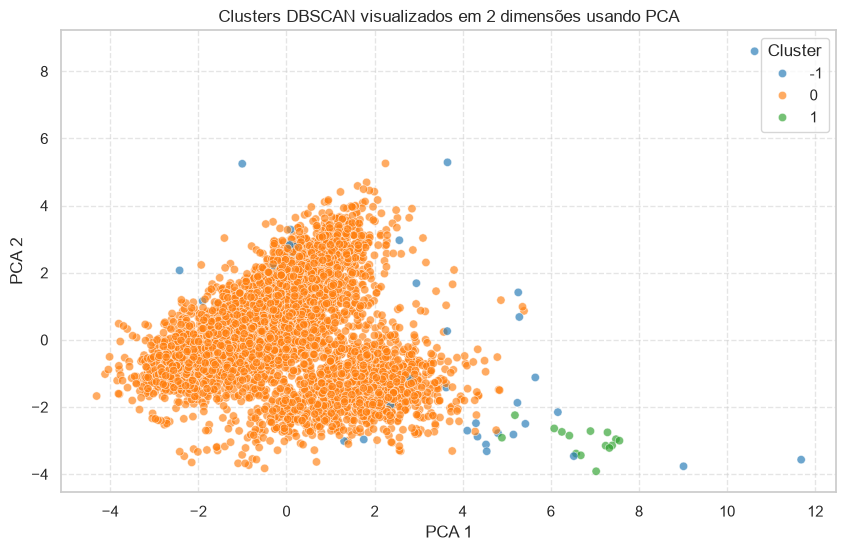

In [12]:
# Adicionando os componentes principais ao DataFrame

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Gráfico PCA 1 x PCA 2, colorido pelos clusters do DBSCAN

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='tab10',
    alpha=0.65
)

plt.title('Clusters DBSCAN visualizados em 2 dimensões usando PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [13]:
# Obtém os pesos (loadings) das variáveis em PCA1 e PCA2

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features
)

print(loadings)

                             PCA1      PCA2
citric_acid              0.021877  0.200545
residual_sugar           0.109679  0.521685
chlorides                0.411598 -0.177807
density                  0.528843  0.201136
pH                       0.006700 -0.288222
sulphates                0.283880 -0.284157
alcohol                 -0.402434 -0.322296
combined_acidity         0.419155 -0.266642
combined_sulfur_dioxide -0.133923  0.512146
quality                 -0.319675 -0.120304


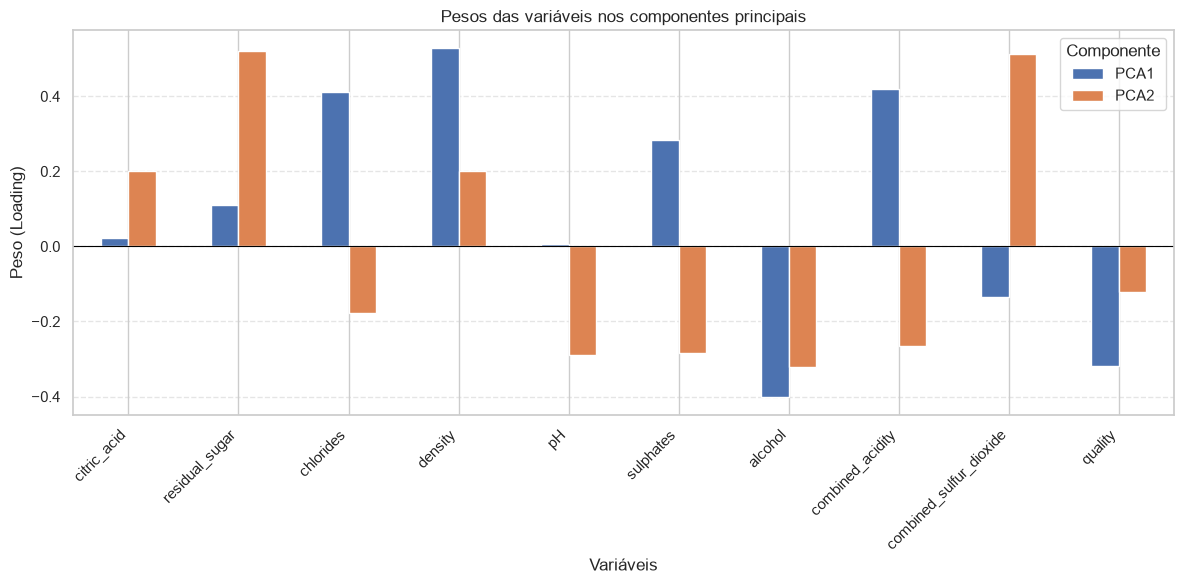

In [14]:
# Gráfico dos pesos das variáveis em PCA1 e PCA2

loadings.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Pesos das variáveis nos componentes principais')
plt.xlabel('Variáveis')
plt.ylabel('Peso (Loading)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Componente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Iniciando a busca pelos melhores parâmetros do DBSCAN...

=== RESULTADO DA ANÁLISE ===
Melhor Silhouette Score: 0.6474
Parâmetros ideais -> eps: 2.0 | min_samples: 5
Quantidade de clusters reais (excluindo ruídos): 2


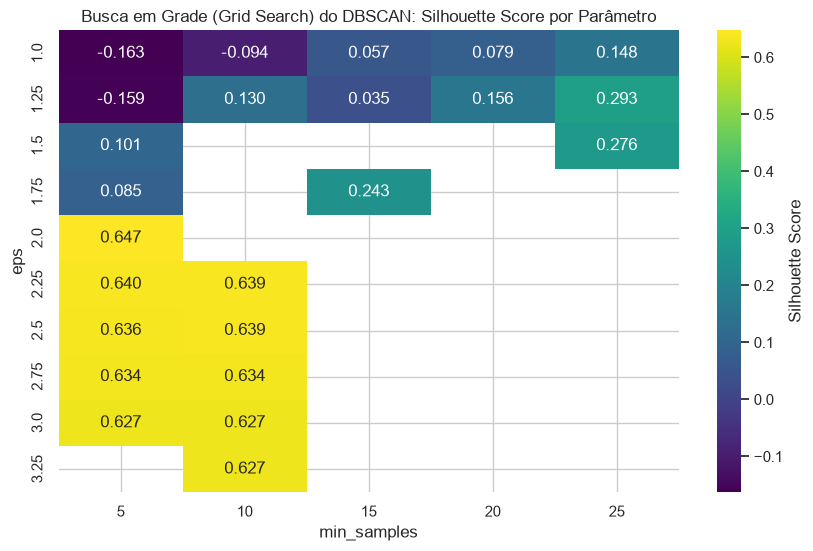

In [10]:
# Definindo os intervalos de busca (ajuste conforme a necessidade dos seus dados)
intervalo_eps = np.arange(1.0, 3.5, 0.25)  # Testa de 1.0 até 3.25 pulando de 0.25 em 0.25
intervalo_min_samples = [5, 10, 15, 20, 25]

# Dicionário para guardar os resultados para o gráfico de calor
resultados_grid = {}

melhor_score = -1
melhor_eps = None
melhor_min_samples = None
melhor_quantidade_clusters = None

print("Iniciando a busca pelos melhores parâmetros do DBSCAN...")

# Loop por todas as combinações de hiperparâmetros
for eps in intervalo_eps:
    for min_samples in intervalo_min_samples:
        # Configura e treina o DBSCAN
        db_teste = DBSCAN(eps=eps, min_samples=min_samples)
        labels_teste = db_teste.fit_predict(X_scaled)
        
        # Identifica as etiquetas únicas
        labels_unicos = set(labels_teste)
        
        # Remove o ruído (-1) da contagem de clusters para a validação da métrica
        if -1 in labels_unicos:
            labels_unicos.remove(-1)
            
        # O cálculo da silhueta exige que existam pelo menos 2 clusters definidos
        if len(labels_unicos) >= 2:
            # Filtra os dados removendo os pontos classificados como ruído (-1)
            mascara_sem_ruido = labels_teste != -1
            X_filtrado = X_scaled[mascara_sem_ruido]
            labels_filtrados = labels_teste[mascara_sem_ruido]
            
            # Calcula o score de silhueta apenas para as amostras válidas
            score = silhouette_score(X_filtrado, labels_filtrados)
            resultados_grid[(eps, min_samples)] = score
            
            # Atualiza os melhores parâmetros se encontrar um score maior
            if score > melhor_score:
                melhor_score = score
                melhor_eps = eps
                melhor_min_samples = min_samples
                melhor_quantidade_clusters = len(labels_unicos)
        else:
            # Caso a combinação resulte em apenas 1 cluster ou apenas ruído
            resultados_grid[(eps, min_samples)] = np.nan

# Exibe o veredito da busca no console
print("\n=== RESULTADO DA ANÁLISE ===")
if melhor_score > -1:
    print(f"Melhor Silhouette Score: {melhor_score:.4f}")
    print(f"Parâmetros ideais -> eps: {melhor_eps} | min_samples: {melhor_min_samples}")
    print(f"Quantidade de clusters reais (excluindo ruídos): {melhor_quantidade_clusters}")
else:
    print("Nenhuma combinação gerou pelo menos 2 clusters válidos para calcular o Silhouette Score.")

# --- CONSTRUÇÃO DO GRÁFICO DE CALOR (HEATMAP) ---
# Organiza os resultados em uma matriz (DataFrame) para o Seaborn
matriz_resultados = pd.DataFrame(index=intervalo_eps, columns=intervalo_min_samples, dtype=float)
for (eps, min_samples), score in resultados_grid.items():
    matriz_resultados.at[eps, min_samples] = score

# Plota o gráfico de calor
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_resultados, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'Silhouette Score'})
plt.title('Busca em Grade (Grid Search) do DBSCAN: Silhouette Score por Parâmetro')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()
